In [2]:
from tabulate import tabulate

# 데이터 정의
table_data = [
    ["도착/출발", "상미규카츠", "파작", "몽탄", "그로어스", "아림당"],
    ["상미규카츠", 0, 23, 42, 39, 43],
    ["파작", 32, 0, 22, 31, 44],
    ["몽탄", 35, 20, 0, 37, 25],
    ["그로어스", 38, 27, 30, 0, 24],
    ["아림당", 38, 34, 19, 22, 0]
]

# tabulate를 이용해 격자형 표로 변환 (headers="firstrow"로 첫 줄을 제목으로 지정)
print(tabulate(table_data, headers="firstrow", tablefmt="grid"))

+-------------+--------------+--------+--------+------------+----------+
| 도착/출발   |   상미규카츠 |   파작 |   몽탄 |   그로어스 |   아림당 |
+=============+==============+========+========+============+==========+
| 상미규카츠  |            0 |     23 |     42 |         39 |       43 |
+-------------+--------------+--------+--------+------------+----------+
| 파작        |           32 |      0 |     22 |         31 |       44 |
+-------------+--------------+--------+--------+------------+----------+
| 몽탄        |           35 |     20 |      0 |         37 |       25 |
+-------------+--------------+--------+--------+------------+----------+
| 그로어스    |           38 |     27 |     30 |          0 |       24 |
+-------------+--------------+--------+--------+------------+----------+
| 아림당      |           38 |     34 |     19 |         22 |        0 |
+-------------+--------------+--------+--------+------------+----------+


위의 표에는 도착시간(장소 A를 기준으로 B->A에 걸리는 시간)과 출발 시간이 모두 나타나 있지만, 애니메이션을 만들 때는 아래의 그래프처럼 도착 시간과 출발 시간의 평균값만 표현하고 간선을 7개로 줄여서 애니메이션을 제작하였습니다.

![graph](graph.jpg)

성공적으로 표준 MP4 'dfs.mp4' 파일로 저장되었습니다!


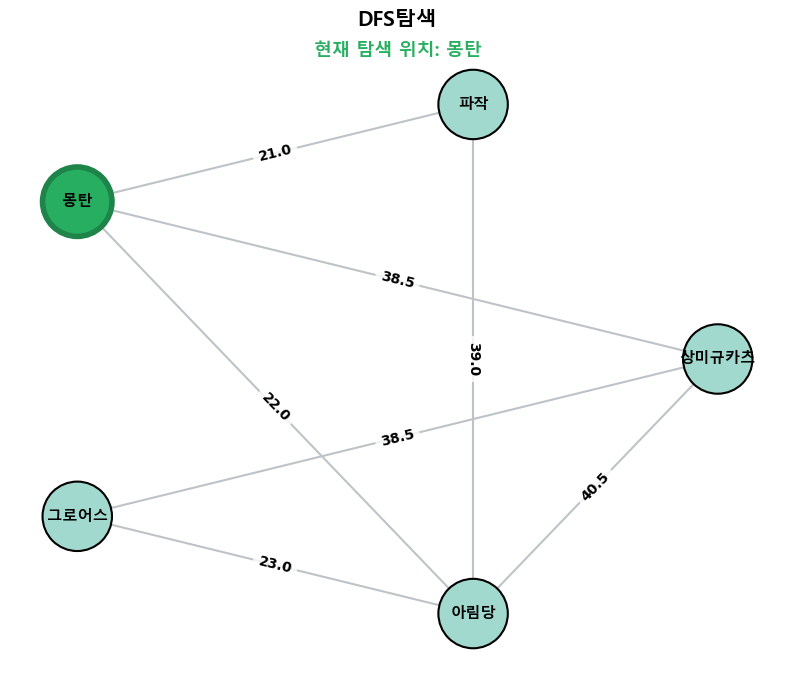

In [3]:
#DFS탐색

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 데이터 정의
places = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
edges_with_weights = [
    ("몽탄", "파작", 21.0),
    ("몽탄", "상미규카츠", 38.5),
    ("몽탄", "아림당", 22.0),
    ("파작", "아림당", 39.0),
    ("그로어스", "상미규카츠", 38.5),
    ("그로어스", "아림당", 23.0),
    ("상미규카츠", "아림당", 40.5)
]

G = nx.Graph()
G.add_nodes_from(places)
for u, v, w in edges_with_weights:
    G.add_edge(u, v, weight=w)

# 원형 레이아웃 고정
pos = nx.circular_layout(G)

# 3. 가중치 반영 DFS 알고리즘 수행
start_node = "몽탄"
visited = set()
frames_states = []

def dfs_weight_recursive(node, passed_edges=None):
    if passed_edges is None:
        passed_edges = []
        
    visited.add(node)
    
    # 현재 상태 기록
    frames_states.append({
        'current_node': node,
        'passed_edges': list(passed_edges)
    })
    
    # [핵심 수정] 이웃 노드들을 '가중치(weight) 오름차순'으로 정렬
    # G[node][neighbor]['weight']를 기준으로 정렬하여 가장 가까운 이웃을 먼저 선택합니다.
    neighbors_sorted_by_weight = sorted(
        G.neighbors(node), 
        key=lambda neighbor: G[node][neighbor]['weight']
    )
    
    for neighbor in neighbors_sorted_by_weight:
        if neighbor not in visited:
            current_edge = tuple(sorted((node, neighbor)))
            passed_edges.append(current_edge)
            
            # 다음 노드로 깊이 우선 탐색 진행
            dfs_weight_recursive(neighbor, passed_edges)

# 가중치 기반 DFS 실행
dfs_weight_recursive(start_node)

# 4. 애니메이션 그리기 설정
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame_idx):
    ax.clear()
    ax.axis('off')
    
    state = frames_states[frame_idx]
    curr_node = state['current_node']
    passed_edges = state['passed_edges']
    
    # 타이틀 표시 (가중치 반영 명시)
    title_text = "DFS탐색"
    status_text = f"현재 탐색 위치: {curr_node}"
    ax.text(0.5, 1.05, title_text, fontsize=15, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 1.00, status_text, fontsize=13, color='#27AE60', fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    
    # 간선 색상 및 두께 설정
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        current_edge = tuple(sorted((u, v)))
        if current_edge in passed_edges:
            edge_colors.append('#2ECC71')  # 지나간 경로: 밝은 초록색
            edge_widths.append(5.0)
        else:
            edge_colors.append('#BDC3C7')  # 일반 간선: 연한 회색
            edge_widths.append(1.5)
            
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color=edge_colors, width=edge_widths)
    
    # 간선 가중치 레이블 그리기
    edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, ax=ax, font_size=10, font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )
    
    # 노드 색상 설정 (현재 노드만 진한 초록색)
    node_colors = []
    node_edge_colors = []
    node_widths = []
    for node in G.nodes():
        if node == curr_node:
            node_colors.append('#27AE60')
            node_edge_colors.append('#1E8449')
            node_widths.append(4.0)
        else:
            node_colors.append('#A2D9CE')
            node_edge_colors.append('black')
            node_widths.append(1.5)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2500, edgecolors=node_edge_colors, linewidths=node_widths)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_family='Malgun Gothic', font_weight='bold')

# 5. 애니메이션 객체 생성
ani = animation.FuncAnimation(fig, update, frames=len(frames_states), interval=1500, repeat=True)

# 6. 동영상 저장
save_filename = 'dfs.mp4'

try:
    # 비디오 인코더 설정을 명확하게 잡아줍니다.
    # extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p']를 넣으면 가장 대중적인 MP4 포맷이 됩니다.
    writer = animation.FFMpegWriter(fps=1, codec='libx264', extra_args=['-pix_fmt', 'yuv420p'])
    
    ani.save(save_filename, writer=writer)
    print(f"성공적으로 표준 MP4 '{save_filename}' 파일로 저장되었습니다!")
    
except Exception as e:
    print(f"MP4 저장에 실패했습니다. 원인: {e}")
    print("대신 어디서나 재생 가능한 GIF 파일로 저장합니다...")
    gif_filename = save_filename.replace('.mp4', '.gif')
    ani.save(gif_filename, writer='pillow', fps=1)

성공적으로 표준 MP4 'bfs.mp4' 파일로 저장되었습니다!


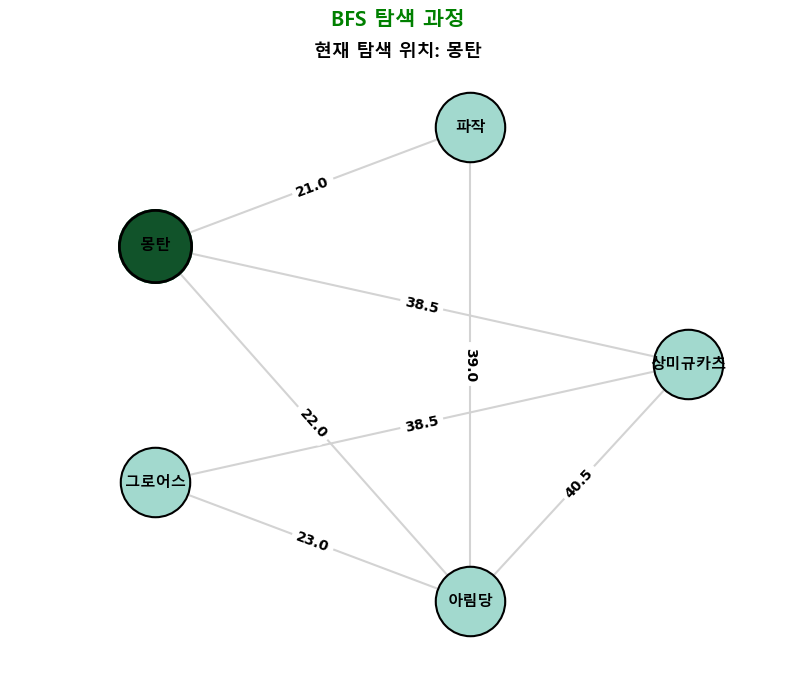

In [4]:
#BFS탐색

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import networkx as nx

# 1. 그래프 데이터 및 가중치 정의
edges = [
    ('몽탄', '파작', 21.0),
    ('몽탄', '상미규카츠', 38.5),
    ('몽탄', '아림당', 22.0),
    ('파작', '아림당', 39.0),
    ('상미규카츠', '아림당', 40.5),
    ('상미규카츠', '그로어스', 38.5),
    ('그로어스', '아림당', 23.0)
]

# NetworkX 그래프 생성
G = nx.Graph()
for u, v, w in edges:
    G.add_edge(u, v, weight=w)

# 2. 이미지 레이아웃과 동일하게 노드 고정 좌표 설정
pos = {
    '몽탄': (-1.0, 0.5),
    '파작': (0.3, 1.0),
    '상미규카츠': (1.2, 0.0),
    '그로어스': (-1.0, -0.5),
    '아림당': (0.3, -1.0)
}

# 3. '몽탄' 시작 BFS 방문 순서 정의
# [큐 변화] [몽탄] -> [파작, 상미규카츠, 아림당] -> [상미규카츠, 아림당] -> [아림당, 그로어스] -> 탐색 완료
bfs_steps = [
    {"current": "몽탄", "visited_nodes": ["몽탄"], "visited_edges": []},
    {"current": "파작", "visited_nodes": ["몽탄", "파작"], "visited_edges": [("몽탄", "파작")]},
    {"current": "상미규카츠", "visited_nodes": ["몽탄", "파작", "상미규카츠"], "visited_edges": [("몽탄", "파작"), ("몽탄", "상미규카츠")]},
    {"current": "아림당", "visited_nodes": ["몽탄", "파작", "상미규카츠", "아림당"], "visited_edges": [("몽탄", "파작"), ("몽탄", "상미규카츠"), ("몽탄", "아림당")]},
    {"current": "그로어스", "visited_nodes": ["몽탄", "파작", "상미규카츠", "아림당", "그로어스"], "visited_edges": [("몽탄", "파작"), ("몽탄", "상미규카츠"), ("몽탄", "아림당"), ("상미규카츠", "그로어스")]}
]

# 4. 시각화 설정 (한글 폰트 설정)
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac 유저는 'AppleGothic'으로 변경하세요.
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(10, 8))

def update(frame):
    ax.clear()
    step_data = bfs_steps[frame]
    current_node = step_data["current"]
    visited_nodes = step_data["visited_nodes"]
    visited_edges = step_data["visited_edges"]
    
    # 상단 텍스트 레이아웃 정의
    ax.text(0.5, 1.05, "BFS 탐색 과정", transform=ax.transAxes, fontsize=15, fontweight='bold', color='green', ha='center')
    ax.text(0.5, 1.00, f"현재 탐색 위치: {current_node}", transform=ax.transAxes, fontsize=13, fontweight='bold', color='black', ha='center')
    
    # 기본 그래프 스케치 (연한 민트 / 연한 회색 간선)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color='#A2D9CE', node_size=2500, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#d3d3d3', width=1.5)
    
    # BFS 방문이 완료된 노드들 하이라이트 (진한 초록)
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=visited_nodes, node_color='#27AE60', node_size=2500, edgecolors='#1E8449', linewidths=4.0)
    
    # 현재 탐색 포커스를 둔 노드 강조
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[current_node], node_color='#11532A', node_size=2700, edgecolors='black', linewidths=2)
    
    # 지나온 탐색 간선 하이라이트 (굵은 초록색)
    if visited_edges:
        nx.draw_networkx_edges(G, pos, ax=ax, edgelist=visited_edges, edge_color='#2ecc71', width=5)
        
    # 노드 이름 출력
    nx.draw_networkx_labels(G, pos, ax=ax, font_family='Malgun Gothic', font_size=11, font_weight='bold')
    
    # 간선 가중치 라벨 출력
    edge_labels = { (u, v): f"{d['weight']}" for u, v, d in G.edges(data=True) }
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax, font_size=10, font_weight='bold')
    
    # 여백 조절 및 축 제거
    ax.set_xlim(-1.6, 1.6)
    ax.set_ylim(-1.3, 1.3)
    ax.axis('off')

# 5. 애니메이션 객체 생성 (무한 반복 설정)
ani = animation.FuncAnimation(fig, update, frames=len(bfs_steps), interval=1500, repeat=True)

# 6. 동영상 안전 저장 가동 (오타 수정 반영)
save_filename = 'bfs.mp4'

try:
    writer = animation.FFMpegWriter(fps=1, codec='libx264', extra_args=['-pix_fmt', 'yuv420p'])
    ani.save(save_filename, writer=writer)
    print(f"성공적으로 표준 MP4 '{save_filename}' 파일로 저장되었습니다!")

except Exception as e:
    print(f"MP4 저장에 실패했습니다. 원인: {e}")
    print("대신 어디서나 재생 가능한 GIF 파일로 저장합니다...")
    gif_filename = save_filename.replace('.mp4', '.gif')
    ani.save(gif_filename, writer='pillow', fps=1)
    print(f"성공적으로 표준 GIF '{gif_filename}' 파일로 저장되었습니다!")

성공적으로 표준 MP4 'prim.mp4' 파일이 저장되었습니다!


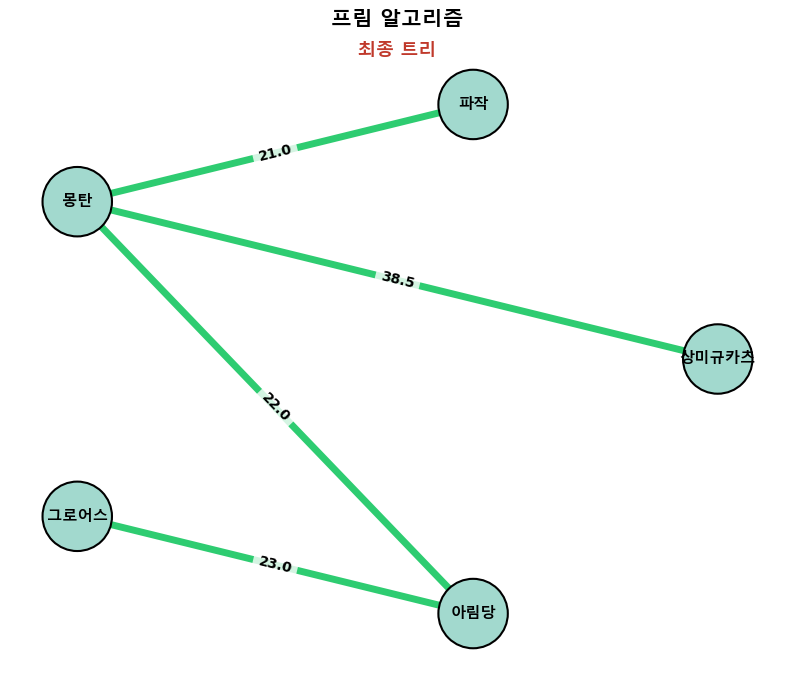

In [5]:
#프림 알고리즘

import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 데이터 정의 (3개 간선이 제거된 형태)
places = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
edges_with_weights = [
    ("몽탄", "파작", 21.0),
    ("몽탄", "상미규카츠", 38.5),
    ("몽탄", "아림당", 22.0),
    ("파작", "아림당", 39.0),
    ("그로어스", "상미규카츠", 38.5),
    ("그로어스", "아림당", 23.0),
    ("상미규카츠", "아림당", 40.5)
]

G = nx.Graph()
G.add_nodes_from(places)
for u, v, w in edges_with_weights:
    G.add_edge(u, v, weight=w)

# 원형 레이아웃 배치 고정
pos = nx.circular_layout(G)

# 3. 프림(Prim) 알고리즘 수행 및 애니메이션 프레임 기록
start_node = "몽탄"
mst_nodes = set([start_node])
mst_edges = []

# 프레임 데이터 저장 리스트
frames_data = []

# 프레임 1: 시작 노드 상태
frames_data.append(('searching', start_node, []))

# 모든 노드가 MST에 포함될 때까지 반복
while len(mst_nodes) < len(G.nodes()):
    possible_edges = []
    
    for node in mst_nodes:
        for neighbor in G.neighbors(node):
            if neighbor not in mst_nodes:
                weight = G[node][neighbor]['weight']
                possible_edges.append((weight, node, neighbor))
                
    possible_edges.sort(key=lambda x: x[0])
    best_weight, u, v = possible_edges[0]
    
    new_node = v
    mst_nodes.add(new_node)
    mst_edges.append((u, v))
    
    frames_data.append(('searching', new_node, list(mst_edges)))

# 탐색 완료 후 최종 화면 프레임 추가 (상태값: 'final')
frames_data.append(('final', None, list(mst_edges)))


# 4. Matplotlib 애니메이션 그리기 설정
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame_idx):
    ax.clear()
    ax.axis('off')
    
    # 데이터 추출
    status_type, curr_node, passed_edges = frames_data[frame_idx]
    
    # 타이틀 및 상태 메시지 설정
    title_text = "프림 알고리즘"
    if status_type == 'final':
        status_text = "최종 트리"
        status_color = '#C0392B'
    else:
        status_text = f"현재 추가된 노드 (프림 알고리즘): {curr_node}"
        status_color = '#27AE60'
        
    ax.text(0.5, 1.05, title_text, fontsize=15, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 1.00, status_text, fontsize=13, color=status_color, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    
    # [핵심 수정: 간선 분기 처리]
    if status_type == 'final':
        # 최종 트리 화면일 때는 오직 프림 알고리즘으로 선택된 간선(passed_edges)만 수집하여 그립니다.
        edges_to_draw = [edge for edge in G.edges() if edge in passed_edges or (edge[1], edge[0]) in passed_edges]
        edge_colors = ['#2ECC71'] * len(edges_to_draw)
        edge_widths = [5.0] * len(edges_to_draw)
        
        # 선택된 간선만 드로잉
        nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, ax=ax, edge_color=edge_colors, width=edge_widths)
        
        # 가중치 라벨도 트리 간선에 해당하는 것만 필터링해서 표시
        edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True) if (u, v) in passed_edges or (v, u) in passed_edges}
    else:
        # 탐색 중에는 구조적 인지를 위해 전체 간선을 다 그리되 색상만 다르게 처리합니다.
        edges_to_draw = list(G.edges())
        edge_colors = []
        edge_widths = []
        for u, v in G.edges():
            if (u, v) in passed_edges or (v, u) in passed_edges:
                edge_colors.append('#2ECC71')  # 채택된 트리 경로
                edge_widths.append(5.0)
            else:
                edge_colors.append('#BDC3C7')  # 나머지 연결망
                edge_widths.append(1.5)
                
        nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, ax=ax, edge_color=edge_colors, width=edge_widths)
        edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}

    # 가중치 텍스트 배치
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, ax=ax, font_size=10, font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )
    
    # [노드 색상 설정]
    node_colors = []
    node_edge_colors = []
    node_widths = []
    
    for node in G.nodes():
        if status_type == 'final':
            node_colors.append('#A2D9CE')
            node_edge_colors.append('black')
            node_widths.append(1.5)
        elif node == curr_node:
            node_colors.append('#27AE60')
            node_edge_colors.append('#1E8449')
            node_widths.append(4.0)
        else:
            node_colors.append('#A2D9CE')
            node_edge_colors.append('black')
            node_widths.append(1.5)

    # 노드 객체와 지명 이름 텍스트 배치
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2500, edgecolors=node_edge_colors, linewidths=node_widths)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_family='Malgun Gothic', font_weight='bold')

# 5. 애니메이션 객체 생성 (프레임 전환 속도: 1.5초)
ani = animation.FuncAnimation(fig, update, frames=len(frames_data), interval=1500, repeat=True)

# 6. MP4 비디오 포맷 인코딩 저장 (재생 오류 차단 옵션 포함)
save_filename = 'prim.mp4'

try:
    writer = animation.FFMpegWriter(fps=1, codec='libx264', extra_args=['-pix_fmt', 'yuv420p'])
    ani.save(save_filename, writer=writer)
    print(f"성공적으로 표준 MP4 '{save_filename}' 파일이 저장되었습니다!")
except Exception as e:
    print("MP4 저장 불가 환경으로 확인되어 GIF 형식 파일로 최종 빌드합니다...")
    gif_filename = save_filename.replace('.mp4', '.gif')
    ani.save(gif_filename, writer='pillow', fps=1)
    print(f"성공적으로 GIF '{gif_filename}' 파일이 저장되었습니다!")

plt.show()

성공적으로 표준 MP4 'kruskal.mp4' 파일이 저장되었습니다!


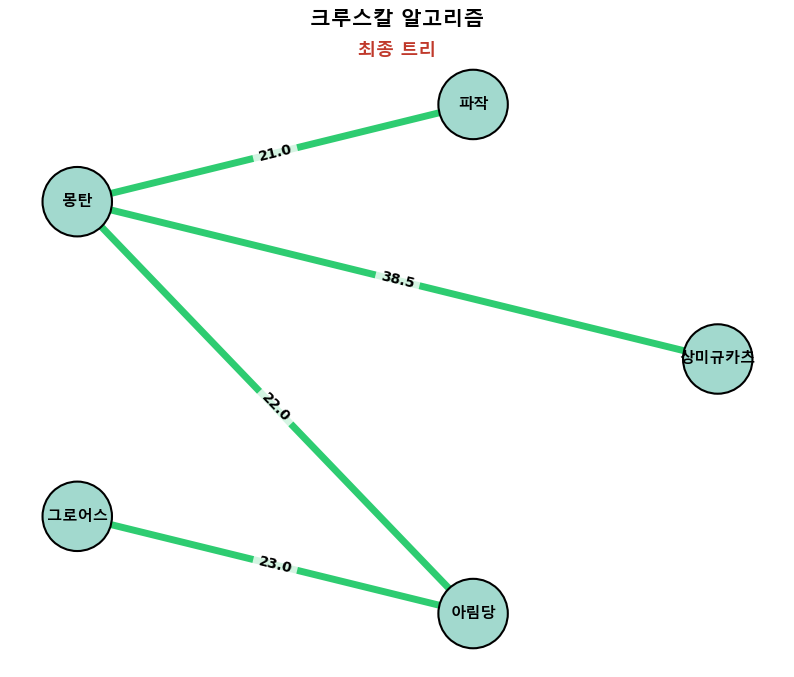

In [6]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# 1. 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'  # Mac은 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 그래프 데이터 정의 (3개 간선이 제거된 형태)
places = ["상미규카츠", "파작", "몽탄", "그로어스", "아림당"]
edges_with_weights = [
    ("몽탄", "파작", 21.0),
    ("몽탄", "상미규카츠", 38.5),
    ("몽탄", "아림당", 22.0),
    ("파작", "아림당", 39.0),
    ("그로어스", "상미규카츠", 38.5),
    ("그로어스", "아림당", 23.0),
    ("상미규카츠", "아림당", 40.5)
]

G = nx.Graph()
G.add_nodes_from(places)
for u, v, w in edges_with_weights:
    G.add_edge(u, v, weight=w)

# 원형 레이아웃 배치 고정
pos = nx.circular_layout(G)

# 3. 크루스칼(Kruskal) 알고리즘을 위한 Union-Find 자료구조 정의
parent = {node: node for node in G.nodes()}

def find(node):
    if parent[node] == node:
        return node
    parent[node] = find(parent[node])
    return parent[node]

def union(node1, node2):
    root1 = find(node1)
    root2 = find(node2)
    if root1 != root2:
        parent[root2] = root1
        return True
    return False

# 가중치 오름차순으로 모든 간선 정렬
all_edges_sorted = sorted(G.edges(data=True), key=lambda x: x[2]['weight'])

# 애니메이션 프레임 데이터 기록
frames_data = []
mst_edges = []

# 프레임 1: 시작 상태 (아무 간선도 선택되지 않음)
frames_data.append(('searching', None, None, []))

# 정렬된 간선을 하나씩 검사하며 크루스칼 알고리즘 진행
for u, v, d in all_edges_sorted:
    weight = d['weight']
    
    # 사이클이 형성되지 않는 경우에만 간선 채택
    if find(u) != find(v):
        union(u, v)
        mst_edges.append((u, v))
        # 탐색 진행 중 프레임 기록 (현재 검사하여 채택한 노드쌍 전달)
        frames_data.append(('searching', u, v, list(mst_edges)))
        
    # 만약 모든 노드가 연결되었다면 (간선 수 = 노드 수 - 1) 조기 종료 가능
    if len(mst_edges) == len(G.nodes()) - 1:
        break

# 탐색 완료 후 최종 완성된 트리 화면 프레임 추가 (상태값: 'final')
frames_data.append(('final', None, None, list(mst_edges)))


# 4. Matplotlib 애니메이션 그리기 설정
fig, ax = plt.subplots(figsize=(10, 8))

def update(frame_idx):
    ax.clear()
    ax.axis('off')
    
    # 데이터 추출
    status_type, node_u, node_v, passed_edges = frames_data[frame_idx]
    
    # 타이틀 및 상태 메시지 설정
    title_text = "크루스칼 알고리즘"
    if status_type == 'final':
        status_text = "최종 트리"
        status_color = '#C0392B'
    elif node_u and node_v:
        status_text = f"현재 연결된 간선 (크루스칼): {node_u} ↔ {node_v}"
        status_color = '#27AE60'
    else:
        status_text = "크루스칼 알고리즘 탐색 시작"
        status_color = '#27AE60'
        
    ax.text(0.5, 1.05, title_text, fontsize=15, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 1.00, status_text, fontsize=13, color=status_color, fontweight='bold', ha='center', va='center', transform=ax.transAxes)
    
    # [간선 지우기 분기 처리]
    if status_type == 'final':
        # 최종 트리 화면일 때는 채택되지 않은 간선은 리스트에서 완전히 제외하여 그리지 않음
        edges_to_draw = [edge for edge in G.edges() if edge in passed_edges or (edge[1], edge[0]) in passed_edges]
        edge_colors = ['#2ECC71'] * len(edges_to_draw)
        edge_widths = [5.0] * len(edges_to_draw)
        
        nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, ax=ax, edge_color=edge_colors, width=edge_widths)
        
        # 가중치 라벨도 트리 간선에 해당하는 것만 필터링
        edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True) if (u, v) in passed_edges or (v, u) in passed_edges}
    else:
        # 탐색 중에는 전체 간선을 다 그리되, 채택된 간선과 대기 간선의 색상을 다르게 분기
        edges_to_draw = list(G.edges())
        edge_colors = []
        edge_widths = []
        for u, v in G.edges():
            if (u, v) in passed_edges or (v, u) in passed_edges:
                edge_colors.append('#2ECC71')  # 크루스칼로 채택된 트리 간선
                edge_widths.append(5.0)
            else:
                edge_colors.append('#BDC3C7')  # 나머지 연결망 간선
                edge_widths.append(1.5)
                
        nx.draw_networkx_edges(G, pos, edgelist=edges_to_draw, ax=ax, edge_color=edge_colors, width=edge_widths)
        edge_labels = {(u, v): f"{d['weight']:.1f}" for u, v, d in G.edges(data=True)}

    # 가중치 텍스트 렌더링
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels=edge_labels, ax=ax, font_size=10, font_weight='bold',
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.8)
    )
    
    # [노드 색상 및 스타일 처리]
    node_colors = []
    node_edge_colors = []
    node_widths = []
    
    for node in G.nodes():
        if status_type == 'final':
            node_colors.append('#A2D9CE')
            node_edge_colors.append('black')
            node_widths.append(1.5)
        # 현재 프레임에서 방금 막 연결을 맺은 두 노드 스포트라이트 강조
        elif node in (node_u, node_v):
            node_colors.append('#27AE60')
            node_edge_colors.append('#1E8449')
            node_widths.append(4.0)
        else:
            node_colors.append('#A2D9CE')
            node_edge_colors.append('black')
            node_widths.append(1.5)

    # 노드 및 지명 이름 레이블 그리기
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=2500, edgecolors=node_edge_colors, linewidths=node_widths)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=11, font_family='Malgun Gothic', font_weight='bold')

# 5. 애니메이션 객체 생성 (프레임 전환 속도: 1.5초)
ani = animation.FuncAnimation(fig, update, frames=len(frames_data), interval=1500, repeat=True)

# 6. MP4 비디오 포맷 호환성 최적화 저장 옵션 적용
save_filename = 'kruskal.mp4'

try:
    writer = animation.FFMpegWriter(fps=1, codec='libx264', extra_args=['-pix_fmt', 'yuv420p'])
    ani.save(save_filename, writer=writer)
    print(f"성공적으로 표준 MP4 '{save_filename}' 파일이 저장되었습니다!")
except Exception as e:
    print("MP4 저장 실패 (FFmpeg 미설치 환경). 안전한 GIF 형식 파일로 저장합니다...")
    gif_filename = save_filename.replace('.mp4', '.gif')
    ani.save(gif_filename, writer='pillow', fps=1)
    print(f"성공적으로 GIF '{gif_filename}' 파일이 저장되었습니다!")

plt.show()